## Agnes Notebook

### dictionary funktion




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib
#Read Initial Test data D_1/ID_1/round_1/phase_1
df_BVP = pd.read_csv('/Users/agnes/Filer/02582_Computational_Data_Analysis/biosignal-analysis/data/raw/dataset/D1_1/ID_1/round_1/phase1/BVP.csv')
df_EDA = pd.read_csv('/Users/agnes/Filer/02582_Computational_Data_Analysis/biosignal-analysis/data/raw/dataset/D1_1/ID_1/round_1/phase1/EDA.csv')
df_TEMP = pd.read_csv('/Users/agnes/Filer/02582_Computational_Data_Analysis/biosignal-analysis/data/raw/dataset/D1_1/ID_1/round_1/phase1/TEMP.csv')
df_HR = pd.read_csv('/Users/agnes/Filer/02582_Computational_Data_Analysis/biosignal-analysis/data/raw/dataset/D1_1/ID_1/round_1/phase1/HR.csv')

#Change time from string to datetime
df_BVP['time_'] = pd.to_datetime(df_BVP['time'], format='mixed')
df_EDA['time_'] = pd.to_datetime(df_EDA['time'], format='mixed')
df_TEMP['time_'] = pd.to_datetime(df_TEMP['time'], format='mixed')
df_HR['time_'] = pd.to_datetime(df_HR['time'], format='mixed')

#df_HRdata.head()
#df_TEMP.head(13)

#Loading All data into dictionary as 
"""
Information = {"Person1": Person1dict, 
                "Person2": Person2dict,
                "Person3": Person3dict, 
                 ... }
Where PersonXdict is: 
PersonXdict = {"Round1": Round1_dict,
                "Round2": Round2_dict
                ... }
RoudXdict = {"Phase1": [start_time], [end_time]
                "Phase2": [start_time], [end time],
                ... }             
"""

#There is also the dataframe for the actual mesaurements
"""
Day1 Person1 - E4
Time| Round | Phase | BVP | EDA | HR | TEMP |

"""

In [ ]:
import os
import pandas as pd
import sys
import matplotlib.pyplot as plt

def build_study_database(base_path):
    # Dictionary 
    information = {}
    # List to collect rows for the flattened "Master" dataframe
    all_data_rows = []

    # Iterate through Cohorts (e.g., D1_1)
    for cohort in sorted(os.listdir(base_path)):
        cohort_path = os.path.join(base_path, cohort)
        if not os.path.isdir(cohort_path): continue

        # Iterate through Subjects (e.g., ID_1) 
        for subject_id in sorted(os.listdir(cohort_path)):
            subject_path = os.path.join(cohort_path, subject_id)
            if not os.path.isdir(subject_path): continue

            person_key = f"{cohort}_{subject_id}"
            information[person_key] = {}

            # Iterate through Rounds (e.g., round_1)
            for round_name in sorted(os.listdir(subject_path)):
                round_path = os.path.join(subject_path, round_name)
                if not os.path.isdir(round_path): continue
                
                information[person_key][round_name] = {}

                # Iterate through Phases (e.g., phase1)
                for phase_name in sorted(os.listdir(round_path)):
                    phase_path = os.path.join(round_path, phase_name)
                    if not os.path.isdir(phase_path): continue

                    # Dictionary to hold the dataframes for this phase
                    signals = {}
                    phase_mins = []
                    phase_maxs = [] 
                    
                    # Load CSVs and apply your datetime conversion
                    for file in os.listdir(phase_path):
                        if file.endswith(".csv"):
                            name = file.replace(".csv", "")
                            df = pd.read_csv(os.path.join(phase_path, file))

                            if 'time' in df.columns:
                                df['time_'] = pd.to_datetime(df['time'], format = 'mixed')
                                phase_mins.append(df['time_'].min())
                                phase_maxs.append(df['time_'].max())

                            signals[name] = df
                    
                    #Calculate global start/end across all high-freq signals
                    start_t = min(phase_mins) if phase_mins else None
                    end_t = max(phase_maxs) if phase_maxs else None

                    information[person_key][round_name][phase_name] = {
                        "data": signals,
                        "times": [start_t, end_t]
                    }

    return information

# Define your absolute path

data_root = r'/Users/agnes/Filer/02582_Computational_Data_Analysis/biosignal-analysis/data/raw/dataset/D1_1/ID_1'
# Build the structure
Information = build_study_database(data_root)



In [2]:
# Definer stien
import os
data_root = r'/Users/agnes/Filer/02582_Computational_Data_Analysis/biosignal-analysis/data/raw/dataset/D1_1/ID_1'

for i, rounds in enumerate(sorted(os.listdir(data_root))):
    print(i,rounds)

0 round_1
1 round_2
2 round_3
3 round_4


In [35]:
dict1 ={}

for i in range(10):
    dict1[f"Agnes phase {i}"] =10
print(dict1)

{'Agnes phase 0': 10, 'Agnes phase 1': 10, 'Agnes phase 2': 10, 'Agnes phase 3': 10, 'Agnes phase 4': 10, 'Agnes phase 5': 10, 'Agnes phase 6': 10, 'Agnes phase 7': 10, 'Agnes phase 8': 10, 'Agnes phase 9': 10}


In [ ]:
Information['Person1_day1']['round1']['phase1']['start_sluttid']=[data_collected_pahse[0], data_collected_pahse[-1]]
Information['Person1_day1']['round1']['phase1']['start_sluttid']=[data_collected_pahse[0], data_collected_pahse[-1]]



In [31]:
phase_times = Information['D1_1_ID_1']['round_1']['phase1']['times']
print(f"Start: {phase_times[0].strftime('%Y-%m-%d %H:%M:%S.%f')}")


Start: 2021-12-17 16:11:54.953125


In [33]:
phase_times = Information['D1_6_ID_2']['round_2']['phase2']['times']
print(f"Phase Duration: {phase_times[0]} to {phase_times[1]}")

Phase Duration: 2022-10-28 16:08:43.453125 to 2022-10-28 16:13:50.437500


In [5]:
df_BVP = pd.read_csv('/Users/agnes/Filer/02582_Computational_Data_Analysis/biosignal-analysis/data/raw/dataset/D1_1/ID_1/round_1/phase1/BVP.csv')
df_BVP['time_'] = pd.to_datetime(df_BVP['time'], format='mixed')
df_BVP.head(10)

,Unnamed: 0,BVP,time,time_
0,0,-61.33,2021-12-17 16:11:54.953125,2021-12-17 16:11:54.953125
1,1,-56.25,2021-12-17 16:11:54.968750,2021-12-17 16:11:54.968750
2,2,-47.83,2021-12-17 16:11:54.984375,2021-12-17 16:11:54.984375
3,3,-35.69,2021-12-17 16:11:55.000000,2021-12-17 16:11:55.000000
4,4,-20.53,2021-12-17 16:11:55.015625,2021-12-17 16:11:55.015625
5,5,-4.10,2021-12-17 16:11:55.031250,2021-12-17 16:11:55.031250
6,6,11.08,2021-12-17 16:11:55.046875,2021-12-17 16:11:55.046875
7,7,22.53,2021-12-17 16:11:55.062500,2021-12-17 16:11:55.062500
8,8,28.63,2021-12-17 16:11:55.078125,2021-12-17 16:11:55.078125
9,9,29.41,2021-12-17 16:11:55.093750,2021-12-17 16:11:55.093750


In [6]:
df_BVP['time_'][3:67].dt.time

3            16:11:55
4     16:11:55.015625
5     16:11:55.031250
6     16:11:55.046875
7     16:11:55.062500
           ...       
62    16:11:55.921875
63    16:11:55.937500
64    16:11:55.953125
65    16:11:55.968750
66    16:11:55.984375
Name: time_, Length: 64, dtype: object

In [7]:
len(df_BVP['time_'][3:67].dt.time)

64

In [8]:
(64-4)/4

15.0

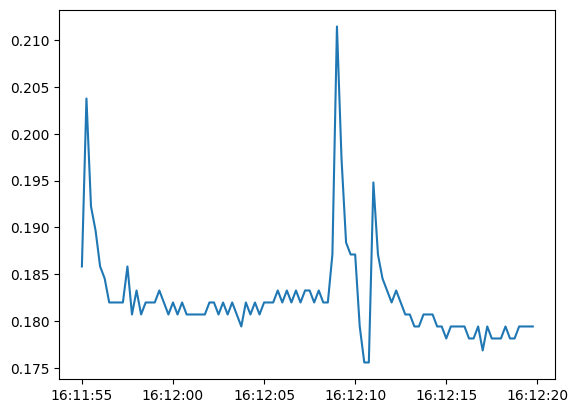

In [13]:
plt.plot(df_EDA['time_'][:100], df_EDA['EDA'][:100])

In [11]:
import pandas as pd
import pathlib
import os

# Definer stien
dataset_path = r'/Users/mathildenielsen/Desktop/02582_CDA/Case2/biosignal-analysis/data/raw/dataset'

alle_data = []

# 1. Loop: Grupper
for gruppe in os.listdir(dataset_path):
    gruppe_sti = os.path.join(dataset_path, gruppe)
    print(gruppe)
    if not os.path.isdir(gruppe_sti): continue
    
    # 2. Loop: Personer
    for person in os.listdir(gruppe_sti):
        person_sti = os.path.join(gruppe_sti, person)

        if not os.path.isdir(person_sti): continue
        
        # 3. Loop: Runder
        for runde in os.listdir(person_sti):
            runde_sti = os.path.join(person_sti, runde)
            if not os.path.isdir(runde_sti): continue
            
            # 4. Loop: Phaser
            for phase in os.listdir(runde_sti):
                phase_sti = os.path.join(runde_sti, phase)
                if not os.path.isdir(phase_sti): continue
                
                # Nu er vi nede ved filerne i den specifikke phase
                for filnavn in os.listdir(phase_sti):
                    if filnavn.endswith('.csv'):
                        fuld_sti = os.path.join(phase_sti, filnavn)
                        
                        # Indlæs data
                        df = pd.read_csv(fuld_sti)
                        
                        # Tilføj metadata så du ved hvor rækkerne stammer fra
                        df['Gruppe'] = gruppe
                        df['Person'] = person
                        df['Runde'] = runde
                        df['Phase'] = phase
                        df['Filnavn'] = filnavn
                        
                        alle_data.append(df)
                        #print(f"Indlæst: {gruppe} > {person} > {runde} > {phase} > {filnavn}")



D1_1
D1_6
D1_3
D1_4
D1_5
D1_2


In [ ]:
import pandas as pd
import pathlib

# Definer stien
base_path = pathlib.Path(r'C:\Din\Hovedmappe')

# Find alle .csv filer i alle undermapper (rekursivt med **)
files = base_path.rglob("*.csv")

df_list = []

for file in files:
    temp_df = pd.read_csv(file)
    # Tilføj en kolonne med filnavnet eller mappen, så du ved hvor data kommer fra
    temp_df['kilde_mappe'] = file.parent.name 
    temp_df['filnavn'] = file.name
    df_list.append(temp_df)

# Saml det hele
final_df = pd.concat(df_list, ignore_index=True)

PosixPath('/Users/mathildenielsen/Desktop/02582_CDA/Case2/biosignal-analysis/data/raw/dataset/D1_2/ID_3/round_2/phase1/BVP.csv')